In [1]:
# [코드 11-1] 데이터프레임 생성 (딕셔너리 방식)
import pandas as pd

data = {
    'name': ['김철수', '이영희', '박민수', '최지원'],
    'test':    [85, 92, 78, 88],
    'assign1': [90, 85, 80, 95],
    'assign2': [88, 90, 75, 92]
}
df = pd.DataFrame(data)
display(df)  # 또는 print(df), 디스플레이는 코랩에서만

,name,test,assign1,assign2
0,김철수,85,90,88
1,이영희,92,85,90
2,박민수,78,80,75
3,최지원,88,95,92


In [6]:
df['name']
df['name'],['test']

(0    김철수
 1    이영희
 2    박민수
 3    최지원
 Name: name, dtype: object,
 ['test'])

In [31]:
# [코드 11-6, 11-7] 열 추출
df['name']                # 한 개 열 → Series 반환
df[['name', 'test']]      # 두 개 이상 열 → DataFrame 반환

# [코드 11-9] 행 순회
for idx, row in df.iterrows():
    print(idx, row['name'], row['test'])

# [코드 11-10] 열 간 연산
df['sum'] = (df['test'] + df['assign1'] + df['assign2'])//3    #sum이라는 열을 하나 더 만든/ sum 값이 강의안 조건과 안맞으니 걍 몫만 구해서 성적합으로

# [코드 11-11] 조건에 맞는 행 추출
df[df['sum'] >= 80]

0 김철수 85
1 이영희 92
2 박민수 78
3 최지원 88


,name,test,assign1,assign2,sum,grade
0,김철수,85,90,88,87,B
1,이영희,92,85,90,89,B
3,최지원,88,95,92,91,A


In [11]:
df[df['sum'] >= 270]

,name,test,assign1,assign2,sum
3,최지원,88,95,92,275


In [9]:
df['name']

,name
0,김철수
1,이영희
2,박민수
3,최지원


In [15]:
df[df['sum'] >= 270]['name']

,name
3,최지원


In [17]:
df[df['sum'] >= 80]
df['name']

['name']

In [19]:
df.loc[df['sum'] >= 270,['name']]

,name
3,최지원


In [35]:
# [코드 11-13] 열 이름 변경
f = df.rename(columns={'test': 'exam'})
df

,name,test,assign1,assign2,sum,grade,result
0,김철수,85,90,88,87,B,pass
1,이영희,92,85,90,89,B,pass
2,박민수,78,80,75,77,C,fail
3,최지원,88,95,92,91,A,pass


In [22]:
# [코드 11-14] 'sum' 열 기준 내림차순 정렬
sort_df = df.sort_values(by='sum', ascending=False)   #특정열의 값만 정렬-어센딩이 오름차정렬인데 false 붙이면 내림차, 안붙이면 오름차
sort_df

,name,test,assign1,assign2,sum
3,최지원,88,95,92,275
1,이영희,92,85,90,267
0,김철수,85,90,88,263
2,박민수,78,80,75,233


In [30]:
# [코드 11-15] 조건에 따라 'grade' 열 생성 (다중 조건)
import numpy as np
df['grade'] = np.where(df['sum'] >= 90, 'A',     #np.where로 성적이라는 열을 만들고 조건문을 넣음
              np.where(df['sum'] >= 80, 'B', 'C'))   #if, else 같은 다중조건도 ㄱ

df

,name,test,assign1,assign2,sum,grade
0,김철수,85,90,88,87.666667,B
1,이영희,92,85,90,89.000000,B
2,박민수,78,80,75,77.666667,C
3,최지원,88,95,92,91.666667,A


In [33]:
df['result'] = np.where(df['sum'] >= 80, 'pass', 'fail')
df

,name,test,assign1,assign2,sum,grade,result
0,김철수,85,90,88,87,B,pass
1,이영희,92,85,90,89,B,pass
2,박민수,78,80,75,77,C,fail
3,최지원,88,95,92,91,A,pass


In [34]:
# [코드 11-17] 빈도수 확인  - 어떤 열에 대해 각 행 값이 몇개인가를 구해줌
df['result'].value_counts()
# pass    3
# fail    1

,count
result,
pass,3
fail,1


In [39]:
# [코드 11-19] 열 삭제
df = df.drop(columns=['result'])

KeyError: "['result'] not found in axis"

In [43]:
#데이터 누락 여부 확인
df.isna().sum()
#분석에 꼭 필요한가 여부에 따라 필요없으면 열째로 날리고 필요하면
#꼭 필요한데 기준값 미만의 누락이면 행들만 각각 날리고 기준이상이면 따로 조치


,0
name,0
test,0
assign1,0
assign2,0
sum,0
grade,0


In [58]:
# [코드 11-22] 누락이 포함된 데이터프레임 생성
import pandas as pd
import numpy as np

data = {
    'name':   ['김철수', '이영희', np.nan, '최지원', '정민호'],
    'gender': ['M', 'F', 'F', np.nan, 'M'],
    'score':  [85, np.nan, 78, 92, np.nan]
}
df1 = pd.DataFrame(data)
display(df1)

,name,gender,score
0,김철수,M,85.0
1,이영희,F,NaN
2,NaN,F,78.0
3,최지원,NaN,92.0
4,정민호,M,NaN


In [46]:
df1.isna()  #True라고 뜬 부분이 누락, 정리해서 보려면 걍 .sum()을 붙이면 훨씬 간단하게 누락치 확인 가능, sum에 sum 또하면 전체 누락치 숫자볼 수 있음

,name,gender,score
0,False,False,False
1,False,False,True
2,True,False,False
3,False,True,False
4,False,False,True


In [48]:
df1.isna().sum()

,0
name,1
gender,1
score,2


In [50]:
df2 = df1.dropna()   #행에 빈 값이 있으면 그 행을 통째로 다 날림/ 그냥 drop은 열삭제이나 na 붙이면 행 삭
df2

,name,gender,score
0,김철수,M,85.0


In [51]:
# [코드 11-26] 'name', 'score' 열만 분석할 경우
# → 'gender' 열의 NaN은 무시하고, name 또는 score가 NaN인 행만 삭제
df2 = df1.dropna(subset=['name', 'score'])
df2

,name,gender,score
0,김철수,M,85.0
3,최지원,NaN,92.0


In [52]:
# [코드 11-27] 원본에 반영하려면
df1.dropna(inplace=True)    #df2에 저장처럼 다른 걸 만드는게 아닌 원본 값 자체를 바꾸는 것/ 원본을 건드는거니 조심해야됨-다시 되돌리려면 데이터프레임을 다시 실행하거나 새로만들거나 해야함
df1

,name,gender,score
0,김철수,M,85.0


In [55]:
# [코드 11-28] 모든 NaN을 0으로 대체
df2 = df1.fillna(0)
df2

,name,gender,score
0,김철수,M,85.0
1,이영희,F,0.0
2,0,F,78.0
3,최지원,0,92.0
4,정민호,M,0.0


In [57]:
# [코드 11-29] 열마다 다른 값으로 대체 (딕셔너리)
df2 = df1.fillna({
    'gender': 'etc',   # 범주형 → 'etc'
    'score':  0        # 수치형 → 0
})
df2

,name,gender,score
0,김철수,M,85.0
1,이영희,F,0.0
2,NaN,F,78.0
3,최지원,etc,92.0
4,정민호,M,0.0


In [64]:
# [코드 11-30] 평균으로 대체 (수치형 권장)
df2 = df1.fillna({'score': df1['score'].mean()})    #이거 뒤에 inplace=true 붙이면 원본값이 대체됨
df2

,name,gender,score
0,김철수,M,85.0
1,이영희,F,85.0
2,NaN,F,78.0
3,최지원,NaN,92.0
4,정민호,M,85.0


In [65]:
# [코드 11-32, 11-33, 11-34] 서로다른 두 DF를 'name' 기준으로 결합
df1 = pd.DataFrame({
    'name':   ['김철수', '이영희', '박민수'],
    'gender': ['M', 'F', 'M'],
    'age':    [21, 22, 20]
})
df2 = pd.DataFrame({
    'name':       ['김철수', '이영희', '박민수'],
    'department': ['컴퓨터공학', '경영학', '토목공학']
})

df3 = pd.merge(df1, df2, on='name')    #on이라는게 합치는 기준점을 제시
display(df3)

,name,gender,age,department
0,김철수,M,21,컴퓨터공학
1,이영희,F,22,경영학
2,박민수,M,20,토목공학


In [66]:
# [코드 11-35, 11-36] 또 다른 키로 추가 결합
df4 = pd.DataFrame({
    'department':       ['컴퓨터공학', '경영학', '토목공학'],
    'head of department': ['이정수', '김영규', '최희재']
})
df5 = pd.merge(df3, df4, on='department')
df5

,name,gender,age,department,head of department
0,김철수,M,21,컴퓨터공학,이정수
1,이영희,F,22,경영학,김영규
2,박민수,M,20,토목공학,최희재


In [67]:
# [코드 11-43] CSV 파일 저장
df.to_csv('precipitation_out.csv')

In [69]:
# [코드 11-40] CSV 파일 읽기     드레그 엔 드롭식으로 직접올리는거도 ㄱㅊ한데 걍 구글드라이브 마운트하면 편함
df = pd.read_csv('precipitation.csv')
df

,year,spring,summer,autumn,winter
0,2017,124.9,612.7,177.9,75.2
1,2018,383.5,620.6,351.3,68.7
2,2019,175.0,508.2,440.8,168.8
3,2020,173.7,1037.6,270.4,47.8
4,2021,330.5,612.8,256.4,13.3


In [76]:
df = pd.read_csv('학급당학생수.csv',encoding='EUC-KR')  #한글 파일의 경우엔 에러가 뜰 확률이 높아 엔코딩으로  이렇게 써줘야함
df

,항목,시점,서울특별시,제주특별자치도
0,전체,2011,29.36,28.88
1,전체,2012,28.63,28.09
2,전체,2013,27.81,27.26
3,전체,2014,26.96,26.46
4,전체,2015,26.19,25.97
5,전체,2016,25.36,25.53
6,전체,2017,24.60,25.25
7,전체,2018,23.76,24.97
8,전체,2019,22.96,24.47
9,전체,2020,22.45,24.15


In [73]:
# [코드 11-49, 11-50] 한글 폰트 설치 (Colab 환경)    이거 설치 안하면ㅁ 그래프 만들때 한글 다 깨짐
!apt-get update -qq                         # ! 붙는게 특징인데 외부명령어임 얘네는
!apt-get install fonts-nanum -qq
!fc-cache -fv

import matplotlib.font_manager as fm
font10 = fm.FontProperties(
    fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    size=10
)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

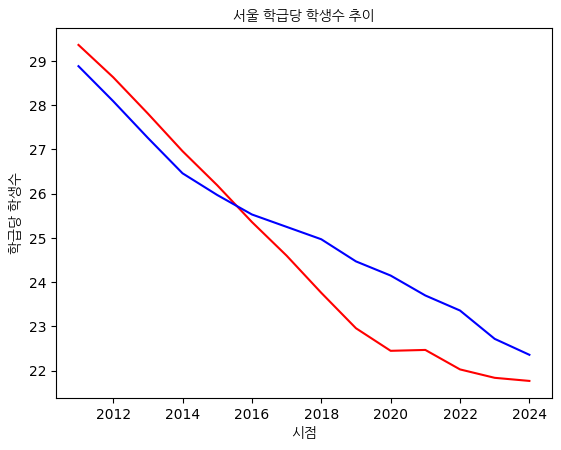

In [79]:
# [코드 11-51] 사용 예시
import matplotlib.pyplot as plt     #그래프 생성 함수

plt.plot(df['시점'], df['서울특별시'],color='red', label='서울특별시')      #어떤 데이터로 그래프를 만들지 지정/ df로 데이터 프레임을 먼저 만들어야 이 방식 쓸 수 있
plt.plot(df['시점'], df['제주특별자치도'], color='blue', label='제주특별자치도')    #x축 y축 컬러 이름 순으로 지정
plt.xlabel('시점', fontproperties=font10)     #x축 이름
plt.ylabel('학급당 학생수', fontproperties=font10)     #y축 이름
plt.title('서울 학급당 학생수 추이', fontproperties=font10)    #그래프 제목
plt.show()    #그래프 보이기

In [ ]:
import pandas as pd   #이 3개는 기본적으로 실행을 돌려야 데이터프레임, csv 파일 읽기, 그래프 생성이 ㄱㄴ함
import numpy as np
import matplotlib.pyplot as plt

In [81]:
df = pd.read_csv('car20240731.csv')   #행이 3498개 열이 13개인 개큰
print(df.shape)
df.head()

(3498, 13)


,업체명,모델명,연료,변속형식,차량형식,자동차 종류,도심주행연비,고속도로연비,CO2배출량(g_km),1회충전주행거리(km),배기량,등급,출시연도
0,볼보,볼보 V60CCB5 AWD,휘발유,자동,하이브리드,승용차,8.7,11.9,175.0,NaN,1969.0,4등급,2024
1,볼보,볼보 XC60T8 AWD,전기+휘발유,자동,PHEV,승용차,16.6,17.1,33.0,61.0,1969.0,PHEV,2024
2,벤츠,Mercedes-Benz GLC 220 d 4MATIC,경유,자동,하이브리드,승용차,13.8,15.5,130.0,NaN,1993.0,2등급,2024
3,벤츠,Mercedes-Benz E 450 4MATIC,휘발유,자동,하이브리드,승용차,9.0,13.1,162.0,NaN,2998.0,4등급,2024
4,랜드로버,더 뉴 레인지로버 P550e SWB,전기+휘발유,자동,PHEV,승용차,11.5,13.1,35.0,80.0,2996.0,PHEV,2024


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3498 entries, 0 to 3497
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   업체명           3498 non-null   object 
 1   모델명           3498 non-null   object 
 2   연료            3498 non-null   object 
 3   변속형식          3498 non-null   object 
 4   차량형식          3498 non-null   object 
 5   자동차 종류        3498 non-null   object 
 6   도심주행연비        3497 non-null   float64
 7   고속도로연비        3497 non-null   float64
 8   CO2배출량(g_km)  3186 non-null   float64
 9   1회충전주행거리(km)  403 non-null    float64
 10  배기량           3187 non-null   float64
 11  등급            3498 non-null   object 
 12  출시연도          3498 non-null   int64  
dtypes: float64(5), int64(1), object(7)
memory usage: 355.4+ KB


In [84]:
df.isna().sum()   #info에 non_nul로도 알 수 있음

,0
업체명,0
모델명,0
연료,0
변속형식,0
차량형식,0
자동차 종류,0
도심주행연비,1
고속도로연비,1
CO2배출량(g_km),312
1회충전주행거리(km),3095


In [86]:
df[['배기량', '고속도로연비','CO2배출량(g_km)']].describe()

,배기량,고속도로연비,CO2배출량(g_km)
count,3187.000000,3497.000000,3186.000000
mean,2557.875118,11.752617,168.908035
std,965.196309,4.508477,48.694492
min,0.000000,0.000000,14.000000
25%,1995.000000,9.800000,137.000000
50%,2199.000000,11.800000,167.000000
75%,2997.000000,14.100000,199.000000
max,6749.000000,92.600000,354.000000


In [87]:
df=df[df['배기량'] > 0]
df[['배기량', '고속도로연비','CO2배출량(g_km)']].describe()

,배기량,고속도로연비,CO2배출량(g_km)
count,3186.000000,3185.000000,3186.000000
mean,2558.677966,12.414662,168.908035
std,964.282913,2.839734,48.694492
min,796.000000,5.900000,14.000000
25%,1995.000000,10.300000,137.000000
50%,2199.000000,12.200000,167.000000
75%,2997.000000,14.400000,199.000000
max,6749.000000,28.000000,354.000000


In [89]:
df1 = df[df['연료'] == '휘발유']
df2 = df[df['연료'] == '경유']

In [90]:
df1

,업체명,모델명,연료,변속형식,차량형식,자동차 종류,도심주행연비,고속도로연비,CO2배출량(g_km),1회충전주행거리(km),배기량,등급,출시연도
0,볼보,볼보 V60CCB5 AWD,휘발유,자동,하이브리드,승용차,8.7,11.9,175.0,NaN,1969.0,4등급,2024
3,벤츠,Mercedes-Benz E 450 4MATIC,휘발유,자동,하이브리드,승용차,9.0,13.1,162.0,NaN,2998.0,4등급,2024
5,볼보,볼보 XC60B6 AWD,휘발유,자동,하이브리드,승용차,8.8,11.5,174.0,NaN,1969.0,4등급,2024
6,볼보,볼보 S60B5,휘발유,자동,하이브리드,승용차,10.5,14.3,143.0,NaN,1969.0,3등급,2024
7,벤츠,Mercedes-Maybach S 580,휘발유,자동,하이브리드,승용차,7.0,10.1,214.0,NaN,3982.0,5등급,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3486,GM,캐딜락 ATS-V,휘발유,자동,내연기관,승용차,7.0,10.2,221.0,NaN,3564.0,5등급,2016
3492,크라이슬러,짚 레니게이드 2.4,휘발유,자동,내연기관,승용차,8.9,11.9,171.0,NaN,2360.0,4등급,2015
3494,현대,아슬란 3.0GDI,휘발유,자동,내연기관,승용차,8.1,11.8,188.0,NaN,2999.0,4등급,2014
3495,현대,아슬란 3.3GDI,휘발유,자동,내연기관,승용차,8.1,11.9,188.0,NaN,3342.0,4등급,2014


In [91]:
df2

,업체명,모델명,연료,변속형식,차량형식,자동차 종류,도심주행연비,고속도로연비,CO2배출량(g_km),1회충전주행거리(km),배기량,등급,출시연도
2,벤츠,Mercedes-Benz GLC 220 d 4MATIC,경유,자동,하이브리드,승용차,13.8,15.5,130.0,NaN,1993.0,2등급,2024
26,벤츠,Mercedes-Benz E 220 d 4MATIC,경유,자동,하이브리드,승용차,14.3,18.9,117.0,NaN,1993.0,1등급,2024
36,벤츠,Mercedes-Benz G 450 d,경유,자동,하이브리드,승용차,9.5,10.8,194.0,NaN,2989.0,4등급,2024
44,BMW,BMW X4 xDrive20d,경유,자동,내연기관,승용차,11.3,14.4,153.0,NaN,1995.0,3등급,2024
47,BMW,BMW 320d,경유,자동,내연기관,승용차,13.5,17.8,124.0,NaN,1995.0,2등급,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3462,BMW,BMW 740d xDrive,경유,자동,내연기관,승용차,10.5,14.7,160.0,NaN,2993.0,3등급,2016
3464,BMW,BMW 740Ld xDrive,경유,자동,내연기관,승용차,10.5,14.7,160.0,NaN,2993.0,3등급,2016
3468,벤츠,E220 d,경유,자동,내연기관,승용차,13.8,17.1,124.0,NaN,1950.0,2등급,2016
3487,포톤,툰랜드(TUNLAND),경유,수동,내연기관,화물차,8.4,10.0,217.0,NaN,2776.0,5등급,2015


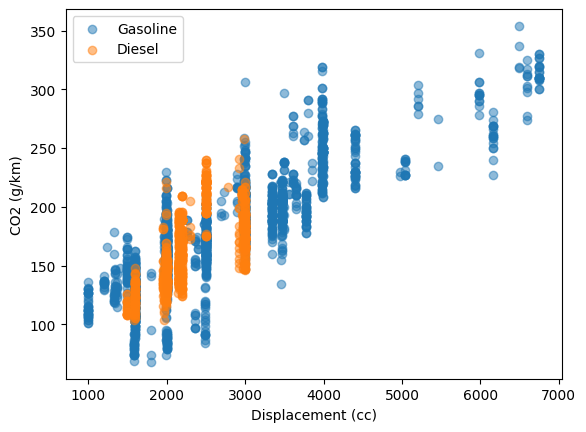

In [93]:
#산점도 그래프
plt.scatter(df1['배기량'], df1['CO2배출량(g_km)'], alpha=0.5, label='Gasoline')
plt.scatter(df2['배기량'], df2['CO2배출량(g_km)'], alpha=0.5, label='Diesel')
plt.xlabel('Displacement (cc)')
plt.ylabel('CO2 (g/km)')
plt.legend()
plt.show()

In [95]:
#상관계수 상정하는 법-0~1 사이로 표현이 되고 1에 가까울수록 상관계가 있다고 봄
r1 = df1['배기량'].corr(df1['CO2배출량(g_km)'])
r2 = df2['배기량'].corr(df2['CO2배출량(g_km)'])

print(f'휘발유 차량 상관계수: {r1:.3f}')
print(f'경유  차량 상관계수: {r2:.3f}')

#즉, 그래프와 상관계수를 보면 기본적으로 배기량과 이산화탄소 배출량은 서로 정비례하며 경유보단 휘발유가 특히 영향을 줌

휘발유 차량 상관계수: 0.856
경유  차량 상관계수: 0.656
